# 04 - Feature Engineering

This notebook prepares the cleaned dataset for machine learning by selecting, transforming, and validating features. The resulting dataset will be used for model training and evaluation.

In [1]:
from pathlib import Path

import pandas as pd

## Load Clean Dataset

Load the dataset and apply the same cleaning step used previously by removing duplicate records. This ensures that feature engineering is performed on the cleaned data.

In [2]:
DATA_PATH = Path("../data/raw/creditcard.csv")

df = pd.read_csv(DATA_PATH)

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (283726, 31)


## Feature Selection

Separate the input features from the target variable. The `Class` column is the prediction target, while all remaining columns are used as input features for the machine learning models.

In [3]:
TARGET_COLUMN = "Class"

X = df.drop(columns=TARGET_COLUMN)
y = df[TARGET_COLUMN]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

Feature Matrix Shape : (283726, 30)
Target Vector Shape  : (283726,)


## Selected Features

Review the list of features that will be used for model development.

In [4]:
selected_features = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str).values
})

selected_features

,Feature,Data Type
0,Time,float64
1,V1,float64
2,V2,float64
3,V3,float64
4,V4,float64
5,V5,float64
6,V6,float64
7,V7,float64
8,V8,float64
9,V9,float64


## Target Variable

Verify the target variable and review its distribution before proceeding with additional feature engineering steps.

In [5]:
y.value_counts().rename({
    0: "Legitimate",
    1: "Fraud"
})

Class
Legitimate    283253
Fraud            473
Name: count, dtype: int64

## Feature Selection Summary

- Total input features: **30**
- Target feature: **Class**
- All selected features are numerical.
- No features have been removed at this stage because each feature may contribute useful information to the fraud detection model.

## Feature Creation

Create additional features from the original transaction data. These features capture useful business information while preserving the integrity of the original dataset.

## Transaction Hour

The `Time` feature represents the number of seconds elapsed since the first transaction. Converting it into transaction hours provides a more interpretable representation for analysis and modeling.

In [6]:
X["TransactionHour"] = (X["Time"] // 3600).astype(int)

X["TransactionHour"].describe()

count    283726.000000
mean         25.844917
std          13.182881
min           0.000000
25%          15.000000
50%          23.000000
75%          38.000000
max          47.000000
Name: TransactionHour, dtype: float64

## Log-Transformed Transaction Amount

Transaction amounts are highly right-skewed. Applying a logarithmic transformation reduces skewness while preserving the ordering of transaction values.

In [7]:
import numpy as np

X["LogAmount"] = np.log1p(X["Amount"])

X[["Amount", "LogAmount"]].head()

,Amount,LogAmount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


## High-Value Transaction Indicator

Create a binary feature indicating whether a transaction amount is greater than the 95th percentile. High-value transactions often require additional fraud monitoring.

In [8]:

threshold = X["Amount"].quantile(0.95)

X["HighValueTransaction"] = (
    X["Amount"] > threshold
).astype(int)

X["HighValueTransaction"].value_counts()

HighValueTransaction
0    269539
1     14187
Name: count, dtype: int64

## Updated Feature Set

Review the newly created features before proceeding to encoding and scaling.

In [9]:
new_features = [
    "TransactionHour",
    "LogAmount",
    "HighValueTransaction"
]

X[new_features].head()

,TransactionHour,LogAmount,HighValueTransaction
0,0,5.014760,0
1,0,1.305626,0
2,0,5.939276,1
3,0,4.824306,0
4,0,4.262539,0


## Feature Creation Summary

Three business-oriented features were added:

- **TransactionHour** – Hour derived from transaction time.
- **LogAmount** – Log-transformed transaction amount to reduce skewness.
- **HighValueTransaction** – Binary indicator for transactions above the 95th percentile.

These features improve interpretability while preserving the original transaction information.

## Encoding Strategy

Review the dataset to determine whether categorical features require encoding. Machine learning algorithms typically require numerical inputs, making this an essential preprocessing step for many datasets.

In [10]:
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Categorical Features: {len(categorical_columns)}")

if categorical_columns:
    print(categorical_columns)
else:
    print("No categorical features found.")

Categorical Features: 0
No categorical features found.


## Feature Type Summary

Summarize the distribution of feature data types after feature creation.

In [11]:
feature_type_summary = pd.DataFrame({
    "Feature Type": X.dtypes.astype(str)
})

feature_type_summary["Feature Type"].value_counts().to_frame("Count")

,Count
Feature Type,
float64,31
int64,2


## Encoding Decision

Since all input features are numerical, no encoding techniques such as One-Hot Encoding, Label Encoding, or Ordinal Encoding are required. The dataset is already in a machine learning-ready format.

In [12]:
print("Encoding Summary")
print("-" * 30)
print(f"Total Features       : {X.shape[1]}")
print(f"Categorical Features : {len(categorical_columns)}")
print(f"Encoded Features     : 0")

print("\nNo encoding required.")

Encoding Summary
------------------------------
Total Features       : 33
Categorical Features : 0
Encoded Features     : 0

No encoding required.


## Scaling Strategy

Machine learning algorithms are often sensitive to differences in feature scales. In this step, we identify the features that require scaling and apply Standard Scaling while preserving the original values.

In [13]:
from sklearn.preprocessing import StandardScaler

## Features Selected for Scaling

The PCA-transformed features (V1–V28) are already standardized. Only the original numerical features and newly engineered continuous features require scaling.

In [14]:
features_to_scale = [
    "Time",
    "Amount",
    "TransactionHour",
    "LogAmount"
]

print("Features to Scale:")
print(features_to_scale)

Features to Scale:
['Time', 'Amount', 'TransactionHour', 'LogAmount']


## Apply Standard Scaling

Standardize the selected features by transforming them to have a mean of approximately zero and a standard deviation of one. The scaled values are stored in new columns to preserve the original data.

In [15]:
scaler = StandardScaler()

print("StandardScaler initialized successfully.")

print("\nFeatures selected for scaling:")
for feature in features_to_scale:
    print(f"- {feature}")

print("\nScaling will be applied in Phase 2.6 using a Scikit-learn preprocessing pipeline.")

StandardScaler initialized successfully.

Features selected for scaling:
- Time
- Amount
- TransactionHour
- LogAmount

Scaling will be applied in Phase 2.6 using a Scikit-learn preprocessing pipeline.


## Scaling Preparation

The scaler has been initialized and the features requiring scaling have been identified. The actual transformation will be performed within the preprocessing pipeline to prevent data leakage and ensure consistency during training and inference.

## Scaling Summary

The continuous features requiring standardization have been identified:

- Time
- Amount
- TransactionHour
- LogAmount

The scaling operation has intentionally been deferred to the preprocessing pipeline (Phase 2.6). This follows production machine learning practices by ensuring that scaling is learned only from the training data and applied consistently during validation, testing, and inference.

## Feature Importance Review

Perform a preliminary assessment of feature relevance using their correlation with the target variable. This provides an initial understanding of which features may contribute to fraud detection before any machine learning models are trained.

In [16]:
correlation_with_target = (
    pd.concat([X, y], axis=1)
      .corr(numeric_only=True)["Class"]
      .drop("Class")
      .sort_values(key=abs, ascending=False)
)

correlation_with_target.head(10)

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64

## Top Features

Review the features that exhibit the strongest relationship with the target variable based on the absolute value of the Pearson correlation coefficient.

In [17]:
top_features = correlation_with_target.head(10)

top_features_df = pd.DataFrame({
    "Feature": top_features.index,
    "Correlation": top_features.values
})

top_features_df

,Feature,Correlation
0,V17,-0.313498
1,V14,-0.293375
2,V12,-0.250711
3,V10,-0.206971
4,V16,-0.187186
5,V3,-0.182322
6,V7,-0.172347
7,V11,0.149067
8,V4,0.129326
9,V18,-0.105340


## Feature Importance Visualization

Visualize the magnitude of the strongest feature correlations with the target variable.

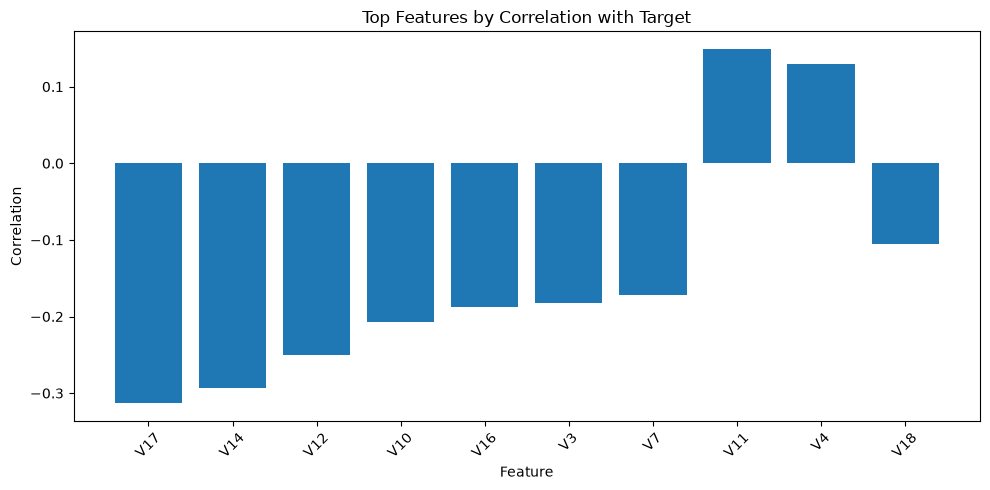

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.bar(
    top_features_df["Feature"],
    top_features_df["Correlation"]
)

plt.title("Top Features by Correlation with Target")
plt.xlabel("Feature")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Feature Engineering Summary

The engineered feature set now consists of:

- Original numerical features
- Three business-derived features
- No categorical features requiring encoding
- A documented scaling strategy for preprocessing

The dataset is now ready for building a reusable preprocessing pipeline.